In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
# prevent processes from using multiple threads
# this is necessary because otherwise the multiprocessing
# in emcee may use more threads than requested
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [47]:
import numpy as np

from seismo_sbi.sbi.configuration import SBI_Configuration
from seismo_sbi.sbi.pipeline import SingleEventPipeline, SBIPipelinePlotter

### Preparation for inversions

I have already downloaded and processed 3 weeks of data between 01.09.2024 - 20.09.2024 for a range of stations in the indo-pacific region.

See [here](https://ds.iris.edu/ieb/index.html?format=text&nodata=404&starttime=2024-09-01&endtime=2024-09-21&minmag=4.8&maxmag=10&orderby=time-desc&src=iris&limit=1000&maxlat=38.76&minlat=-23.64&maxlon=177.95&minlon=69.40&zm=4&mt=ter) for a map of relevant events. I have pre-processed a range of these as well. 

In [48]:
config = SBI_Configuration()

# specifying output filepaths, etc. 

main_config_options = dict(
    run_name='cps',
    output_directory= '/data/alex/cps/alex',
    job_name='testing',
    generate_dataset= True,
    num_jobs= 40 # number of cores to utilise for all tasks
)

config.parse_main_options(main_config_options)

sbi_pipeline = SingleEventPipeline(config.pipeline_parameters)


### Section 1: Fixed Location Source Inversion

This section performs a fixed location event inversion. 

In [49]:
# forward modelling and processing options

simulation_config_options = dict(
    simulation_type= 'cps_precomputed', # 'instaseis' or 'cps'
    components= 'ZEN',
    stations_path= '../scripts/configs/long_valley/stations.txt',
    station_components_path= '../scripts/configs/long_valley/components.json',
    seismogram_duration= 200,
    sampling_rate= 0.5,
    syngine_address= "/data/shared/prem_a_20s", # if no local version, can use "syngine://prem_i_2s"
    processing=dict(
        filter=dict(
            type= 'bandpass',
            freqmin= 0.025,
            freqmax= 0.1,
            corners= 4,
            zerophase= False),
        sampling_rate=1.0
    ),
    
)

# initial parameters configurations
# LV2 Stable inversions for complete moment tensors
# LV2a Volcanic earthquake 11/22/1997 17:20:35.1 37.636 −118.936 4.8
seismic_source_config=dict(
  inference=dict(
    moment_tensor=dict(
      #         [Mrr, Mtt, Mpp, Mrt, Mrp, Mtp]
      fiducial= [1.e+14, 1.e+14, 1.e+14, 1.e+14, 1.e+14, 1.e+14],
      stencil_deltas= [1.e+10, 1.e+10, 1.e+10, 1.e+10, 1.e+10, 1.e+10],
      bounds= [[-5.e+14, -5.e+14, -5.e+14, -5.e+14, -5.e+14, -5.e+14],
              [5.e+14, 5.e+14, 5.e+14, 5.e+14, 5.e+14, 5.e+14]]
        ),
    ),
  nuisance=dict( # we fix the source location here
    source_location=dict(
      #         [lat, long, depth, time]
      fiducial= [37.636, -118.936, 5, 0],
      bounds= [ 37.636, -118.936, 5, 0]
      ),
    velocity_model=dict(
      fiducial='/home/alex/work/seismo-sbi/scripts/data/SoCal.plain.txt',
      bounds=('/home/alex/work/seismo-sbi/scripts/data/SoCal.plain.txt', 5)
    )
  ),
)

# dataset generation parameters

dataset_config_options = dict(
    num_simulations= 4000,
    sampling_method= dict(
        moment_tensor= 'uniform',
        source_location='constant',
        velocity_model='velocity model'),
   use_fisher_to_constrain_bounds = 15,
)

config.parse_seismic_context(simulation_config_options)
config.parse_parameters(seismic_source_config)
config.parse_simulations_options(dataset_config_options)

sbi_pipeline.load_seismo_parameters(config.sim_parameters, config.model_parameters, config.dataset_parameters)

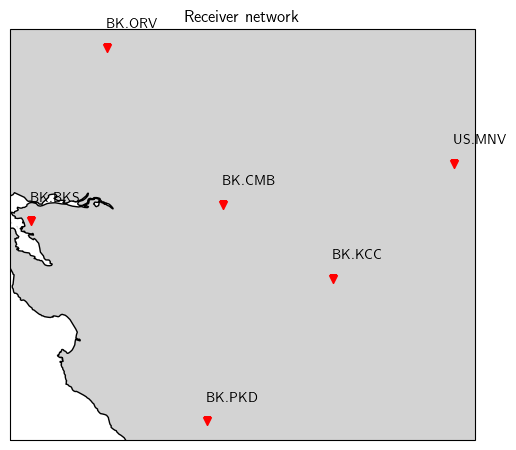

In [50]:
sbi_pipeline.simulation_parameters.receivers.plot()

### Real noise and event configuration

I have pre-processed a database of real noise, found under `/data/alex/noise/indo_pacific/long_period_samples`. These are concurrent 30 minute samples of noise across the station array over the period we are studying. 

There is also a range of events, $>M_W \: 5$, found under `/data/alex/indo_pacific/events_0.5hz`. These have also been preprocessed to a fixed length and sampling rate.

In [51]:
job_data_configuration = dict(  
    real_events=dict( # specify path to the real event data
        # talaud_fixed= '/data/alex/indo_pacific/events_0.5hz/TALAUD_ISLANDS_INDONESIA_20240913_063349_Lat4.5327_Lon126.5069_event_filtered_0.5hz.h5'
    ),
    simulations=dict( # we don't run any artificial events here
        random_events= 0,#100,
        fixed_events= [],
        # custom_events = {}
        custom_events= {'synthetic_dc': {'moment_tensor': [3.e+14, -3.e+14, 0 ,0, 0, 0], 'source_location': [37.636, -118.936, 5, 0], 'use_fiducial': True}},
        # custom_events= {'synthetic_dc': {'moment_tensor': [1.e+14, 1.e+14, 1.e+14, 1.e+14, 1.e+14, 1.e+14], 'source_location': [37.636, -118.936, 5, 0], 'use_fiducial': True}},

    ),
    noise_models=dict(
        gaussian_noises= [1.e-2]
    ),
    plots=dict(
        async_plotting= True,
        test_posteriors= dict(
            chain_consumer= 
                [[['theory_optimal_score', 'real_noise'], ['gaussian_likelihood', 'real_noise']]]
        ),
        disable_plotting= False
    )
)

config.parse_jobs_config(job_data_configuration)

In [52]:
test_jobs_paths = sbi_pipeline.simulate_test_jobs(config.dataset_parameters, config.test_job_simulations)

Running simulations: : 0it [00:00, ?it/s]
Running simulations: 100%|██████████| 1/1 [00:00<00:00,  4.49it/s]


In [53]:
sbi_pipeline.compute_data_vector_properties(test_jobs_paths, config.real_event_jobs)


In [54]:
compression_config = {'theory_optimal_score':
    {'noise_level':  1.e-2}  # this is the noise level used in the Gaussian noise model
}
config.parse_compression_options(compression_config)

score_compression_data, covariance_gradients = sbi_pipeline.compute_required_compression_data(
    config.compression_methods,
    config.model_parameters,  
)


using fiducial: True
using fiducial: False


In [55]:
sbi_pipeline.load_compressors(config.compression_methods, score_compression_data, covariance_data=compression_config['theory_optimal_score']['noise_level'], extra_gradients=covariance_gradients)


/tmp/ipykernel_2889544/2879851048.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdBu', 256)


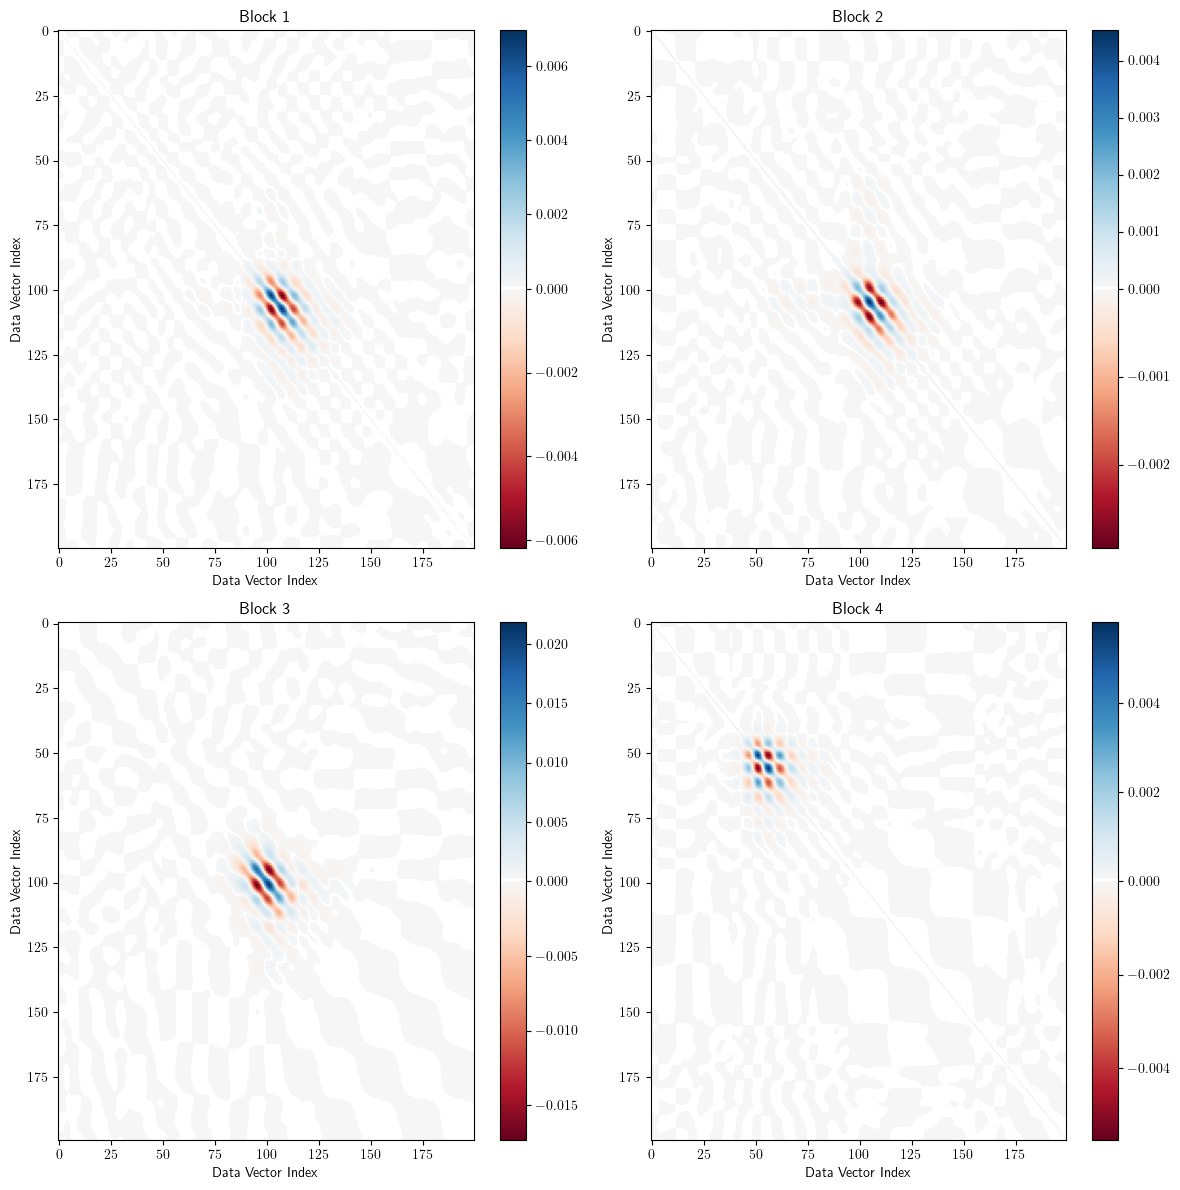

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm, ListedColormap
from matplotlib import cm

cov_blocks = sbi_pipeline.compressors['theory_optimal_score'].C.covariance_matrix_arrays

# Custom RdBu with pure white at zero
cmap = cm.get_cmap('RdBu', 256)
colors = cmap(np.linspace(0, 1, 256))
mid_idx = 128  # center index
colors[mid_idx] = [1, 1, 1, 1]  # pure white
custom_cmap = ListedColormap(colors)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Flatten so enumerate works over all subplots
for i, ax in enumerate(axs.flat):
    block = cov_blocks[i]
    norm = TwoSlopeNorm(vmin=np.min(block), vcenter=0, vmax=np.max(block))
    im = ax.imshow(block, cmap=custom_cmap, norm=norm, aspect='auto')
    ax.set_title(f'Block {i+1}')
    ax.set_xlabel('Data Vector Index')
    ax.set_ylabel('Data Vector Index')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [113]:
inference_options = dict(
  sbi=dict(
    method= 'posterior',
    noise_model= dict(
      type= 'gaussian',
      noise_level= 1.e-2,
    ),
  ),
  likelihood= dict(
    run= True, # we wish to run a likelihood inversion
    ensemble= False,
    covariance= 'empirical',
    num_samples= 50000,
    walker_burn_in= 3000,
    move_size= [0.001, 0.0003],
  ),
)
config.parse_sbi_config(inference_options)

sbi_pipeline.load_test_noises(config.sbi_noise_model, config.test_noise_models)

Training noise type: gaussian


In [58]:
# now load the relevant event
job_data = sbi_pipeline.create_job_data(test_jobs_paths, config.real_event_jobs)

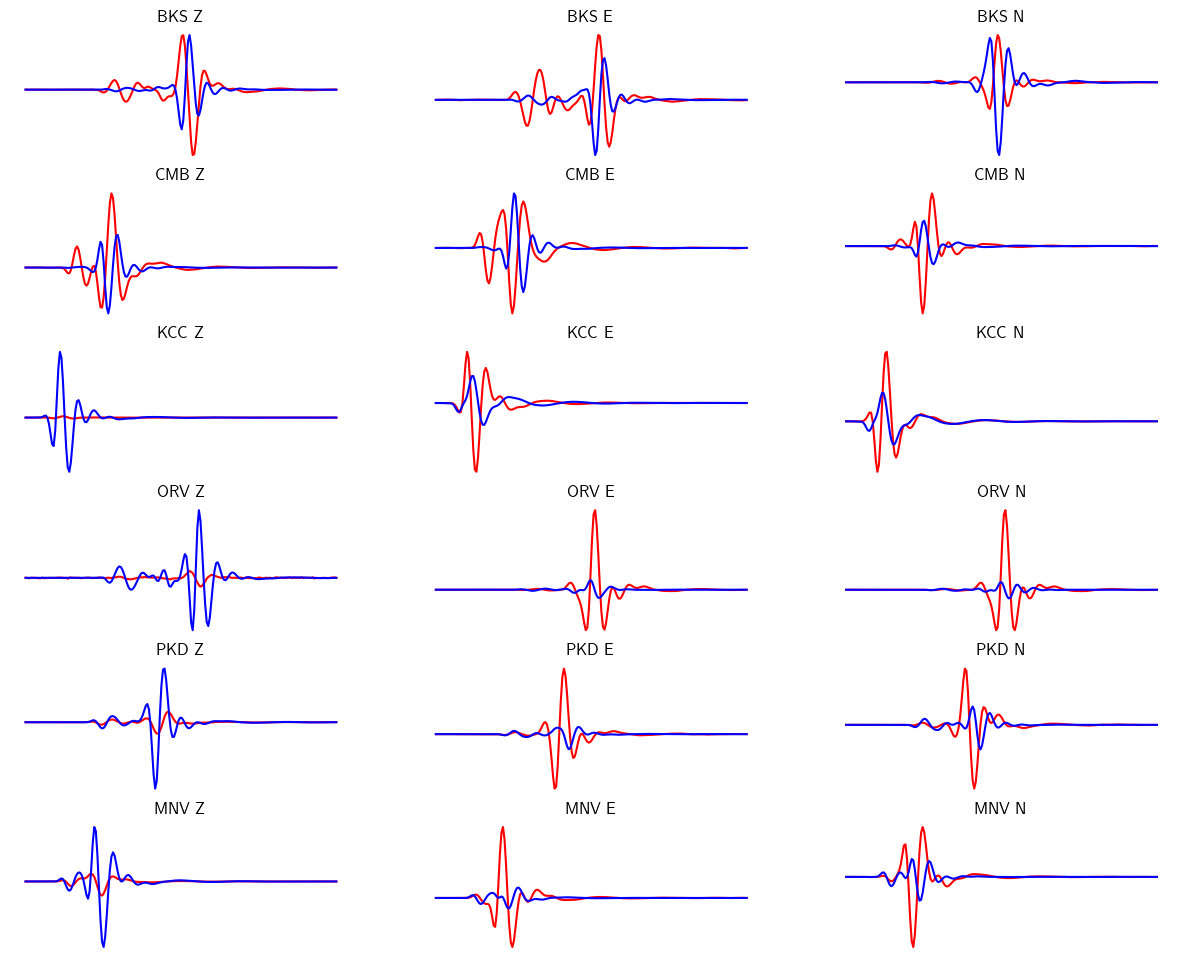

In [59]:
# let's plot the event + the GCMT solutions

plotter = SBIPipelinePlotter('', sbi_pipeline.parameters)
plotter.plot_synthetic_misfits(
    job_data[0], 
    sbi_pipeline.simulation_parameters.receivers, 
    score_compression_data.data_fiducial, 
    event_location= (4.5327, 126.5069),
    only_raw=True,
    savefig=False )


### Prepare for inversions

We now move parameter dictionaries into vector forms to prepare for inversions. Certain inversion configurations also update how we do the dataset generation stage, but we don't use that here.

In [60]:
dataset_details = config.dataset_parameters
param_names = sbi_pipeline.parameters.names

sim_name, test_noise, D, theta0_dict, covariance, priors = job_data[0]
try:
    sbi_pipeline.training_noise_sampler.set_adaptive_covariance_with_misc_data(covariance)
except AttributeError:
    pass
theta0, _  = sbi_pipeline.compute_theta0_and_update_dataset(param_names, dataset_details, theta0_dict)

### Find expansion point $\mathbf{m}_*$

We can compute the maximum-likelihood estimate of the model parameters $\mathbf{m}_*$ using some form of least squares minimisation.

Since this first inversion is a moment tensor inversion, this is linear and therefore solved in one step of least squares. 

In [61]:
compression_data = sbi_pipeline.find_mle_and_set_compressor(D, covariance, priors, dataset_details, extra_gradients=covariance_gradients)

using fiducial: True


Performing iterative least squares for MLE fiducial:   0%|          | 0/10 [00:00<?, ?it/s]

using fiducial: True
chi^2: 7.81736, damping lambda: 0.007
New MLE:
moment_tensor: [2.948e+14, -3.014e+14, -9.936e+12, 1.169e+12, -4.831e+12, -4.386e+12]


Performing iterative least squares for MLE fiducial:  10%|█         | 1/10 [00:00<00:06,  1.44it/s]

using fiducial: True
chi^2: 0.31660, damping lambda: 0.004
New MLE:
moment_tensor: [2.918e+14, -3.171e+14, 5.949e+11, 5.496e+12, 1.136e+13, 8.437e+11]


...

using fiducial: True
chi^2: 0.42598, damping lambda: 0.003
New MLE:
moment_tensor: [2.870e+14, -3.187e+14, -5.117e+13, -5.396e+12, 1.858e+13, -1.023e+13]


Performing iterative least squares for MLE fiducial:  90%|█████████ | 9/10 [00:06<00:00,  1.36it/s]

using fiducial: True
chi^2: 1.09621, damping lambda: 0.003
New MLE:
moment_tensor: [2.937e+14, -2.952e+14, 1.659e+13, 1.745e+12, 1.011e+13, 1.389e+13]


Performing iterative least squares for MLE fiducial: 100%|██████████| 10/10 [00:07<00:00,  1.37it/s]

using fiducial: True


Constrain the prior according around the best model parameters using the Fisher information.

In [62]:
from seismo_sbi.sbi.scalers import FlexibleScaler
from seismo_sbi.sbi.inference import SBI_Inference
import torch

# sbi_pipeline.use_kernel_simulator_if_possible(compression_data, dataset_details.sampling_method)

# if dataset_details.use_fisher_to_constrain_bounds:
#     dataset_details = sbi_pipeline.use_fisher_to_constrain_bounds(dataset_details, compression_data)

compressor = sbi_pipeline.compressors['theory_optimal_score']
x_0 = compression_data.theta_fiducial

print('MLE', x_0)
print('bounds', sbi_pipeline.parameters.bounds)


MLE [ 2.93664678e+14 -2.95177971e+14  1.65941963e+13  1.74477808e+12
  1.01085913e+13  1.38908945e+13]
bounds {'moment_tensor': [[-500000000000000.0, -500000000000000.0, -500000000000000.0, -500000000000000.0, -500000000000000.0, -500000000000000.0], [500000000000000.0, 500000000000000.0, 500000000000000.0, 500000000000000.0, 500000000000000.0, 500000000000000.0]], 'source_location': [37.636, -118.936, 5, 0], 'velocity_model': ('/home/alex/work/seismo-sbi/scripts/data/SoCal.plain.txt', 5)}


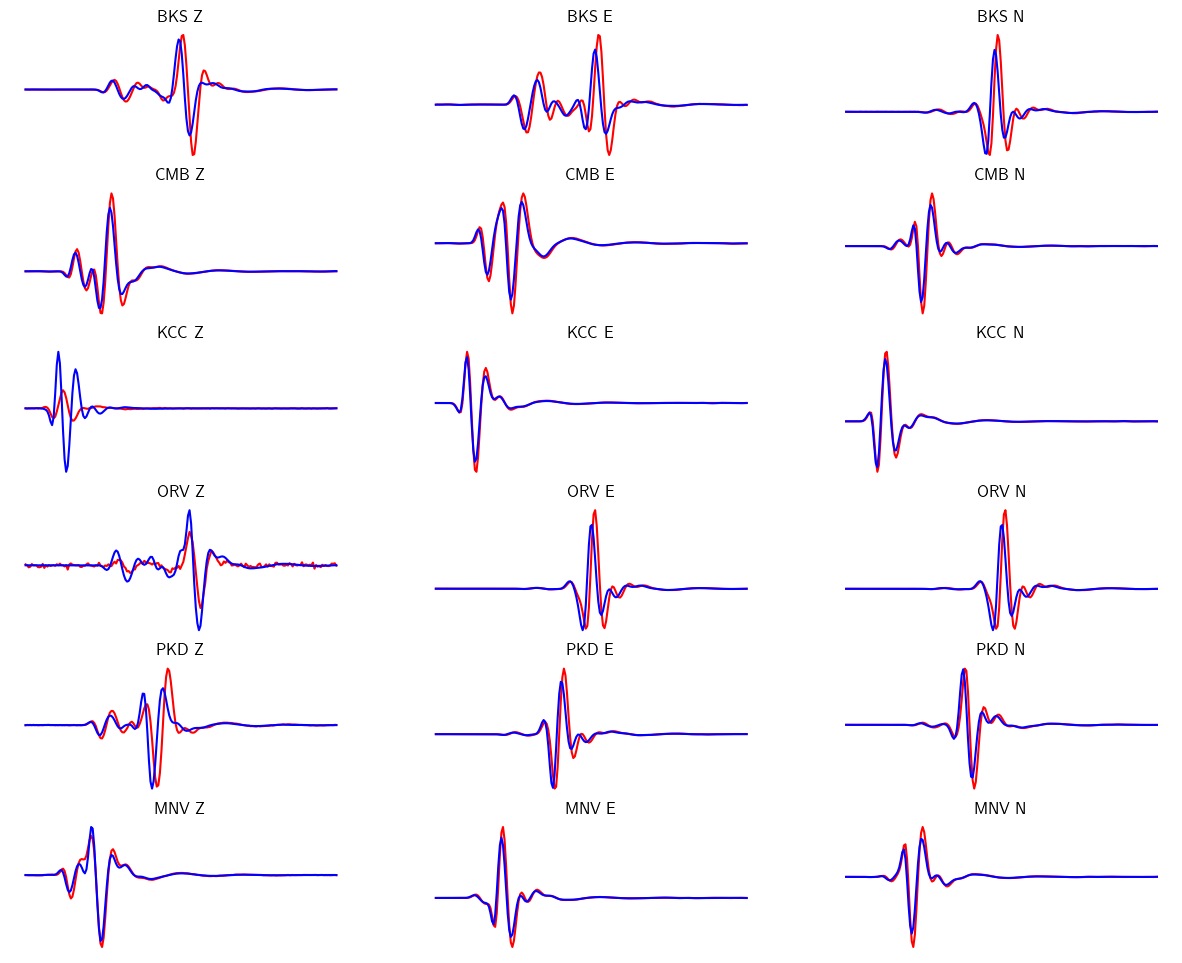

In [63]:
# let's plot the event + the GCMT solutions

# gcmt_mt_solution  = np.array([-0.741, -0.351 , 1.092, -0.020, -2.047,  2.948]) * 1.e16
best_fit_synthetics = sbi_pipeline.simulator_wrapper.simulation_callable(x_0)

plotter = SBIPipelinePlotter('', sbi_pipeline.parameters)
plotter.plot_synthetic_misfits(
    job_data[0], 
    sbi_pipeline.simulation_parameters.receivers, 
    best_fit_synthetics, 
    event_location= (4.5327, 126.5069),
    only_raw=True,
    savefig=False )


Build a dataset of simulations from the constrained prior, before compressing the dataset and preprocessing it in preparation for the training stage. 

In [64]:

sbi_pipeline.ground_truth_scaler = FlexibleScaler(sbi_pipeline.parameters)
statistic_scaler = sbi_pipeline.ground_truth_scaler
x_0_scaled = statistic_scaler.transform(x_0.reshape(1,-1)).reshape(-1)

dataset = sbi_pipeline.generate_simulation_data(dataset_details, priors=priors)
raw_compressed_dataset = sbi_pipeline.data_manager.compress_dataset(
    compressor, param_names, sbi_pipeline.simulations_output_path, sbi_pipeline.training_noise_sampler
)
dataset.clear_all_outputs()

train_data = torch.Tensor(sbi_pipeline.scale_dataset(raw_compressed_dataset, sbi_pipeline.ground_truth_scaler, statistic_scaler))
train_data, raw_compressed_dataset = sbi_pipeline.clean_train_data(train_data, raw_compressed_dataset)

Compressing dataset: 100%|██████████| 4000/4000 [00:30<00:00, 132.09it/s]


Removed 81 rows due to high relative compression error.


Once the dataset has been prepared, we can proceed with the training stage. Here we use a pre-prepared architecture for modelling the probability density of the posterior distribution. 

Once trained, we can draw samples near-instantly from the trained neural density estimator.

In [65]:
from seismo_sbi.sbi.types.results import InversionResult, InversionData, InversionConfig

sbi_model = SBI_Inference('posterior', sbi_pipeline.num_dim)

sbi_model.build_amortised_estimator(train_data)

sample_results, _ = sbi_model.sample_posterior(x_0_scaled, num_samples=10000)

# package up the results
theta0_scaled = sbi_pipeline.ground_truth_scaler.transform(theta0.reshape(1,-1)).reshape(-1)
inversion_data = InversionData(theta0_scaled, sample_results, sbi_pipeline.ground_truth_scaler, compression_data)
inversion_result = InversionResult(sim_name, inversion_data, InversionConfig("", "gaussian", "theory_optimal_score"))



 Neural network successfully converged after 157 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

In [66]:
from copy import deepcopy
from seismo_sbi.sbi.types.results import JobResult
job_result = JobResult(raw_compressed_dataset, x_0, deepcopy(sbi_pipeline.ground_truth_scaler))

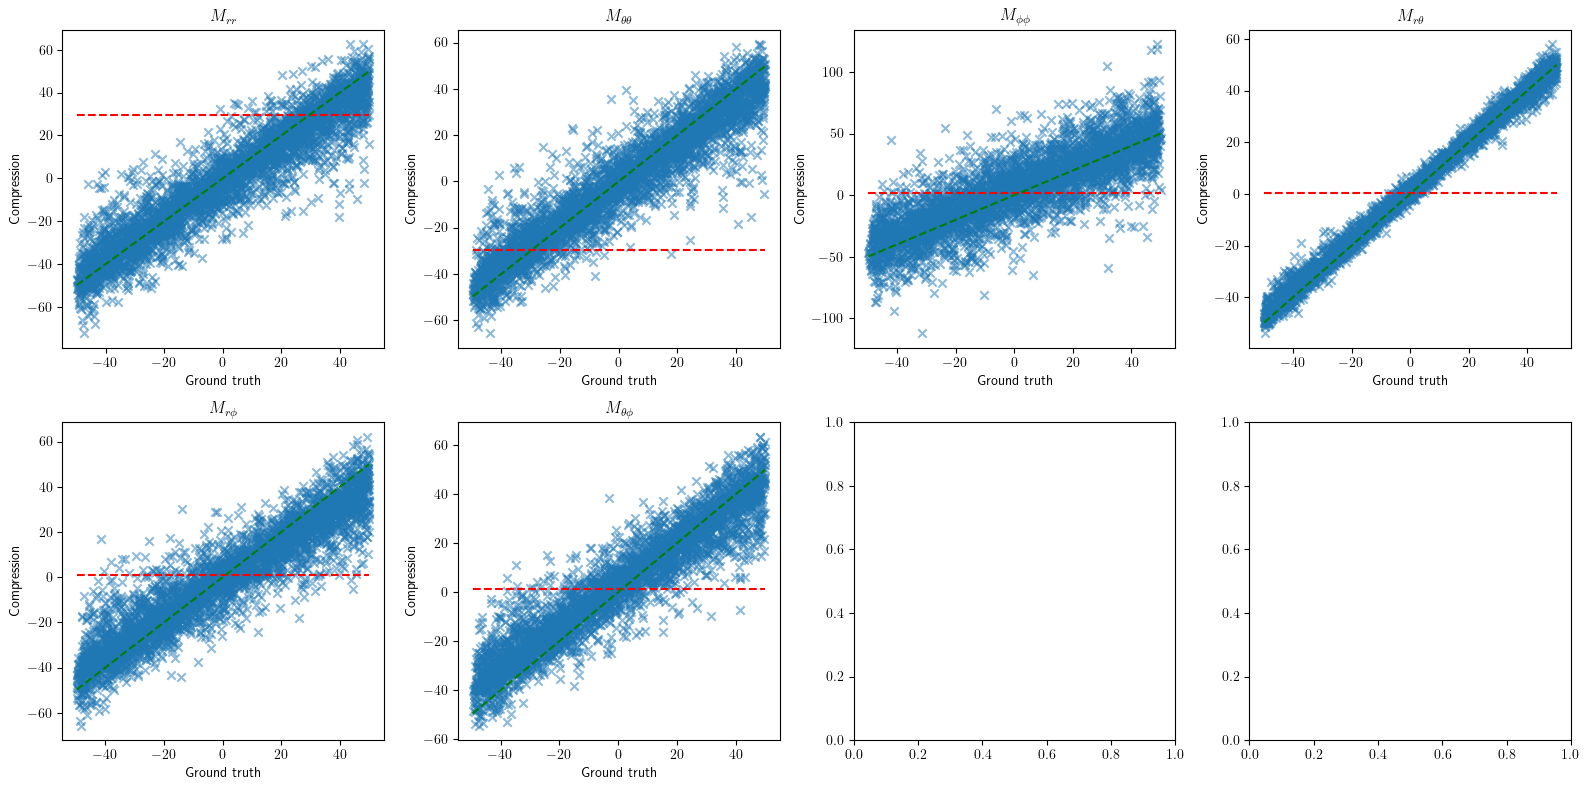

In [68]:
sbi_pipeline.plot_result(job_result, inversion_result, output=False)

Quick sanity check: what does our best fitting solution look like compared to the observations?

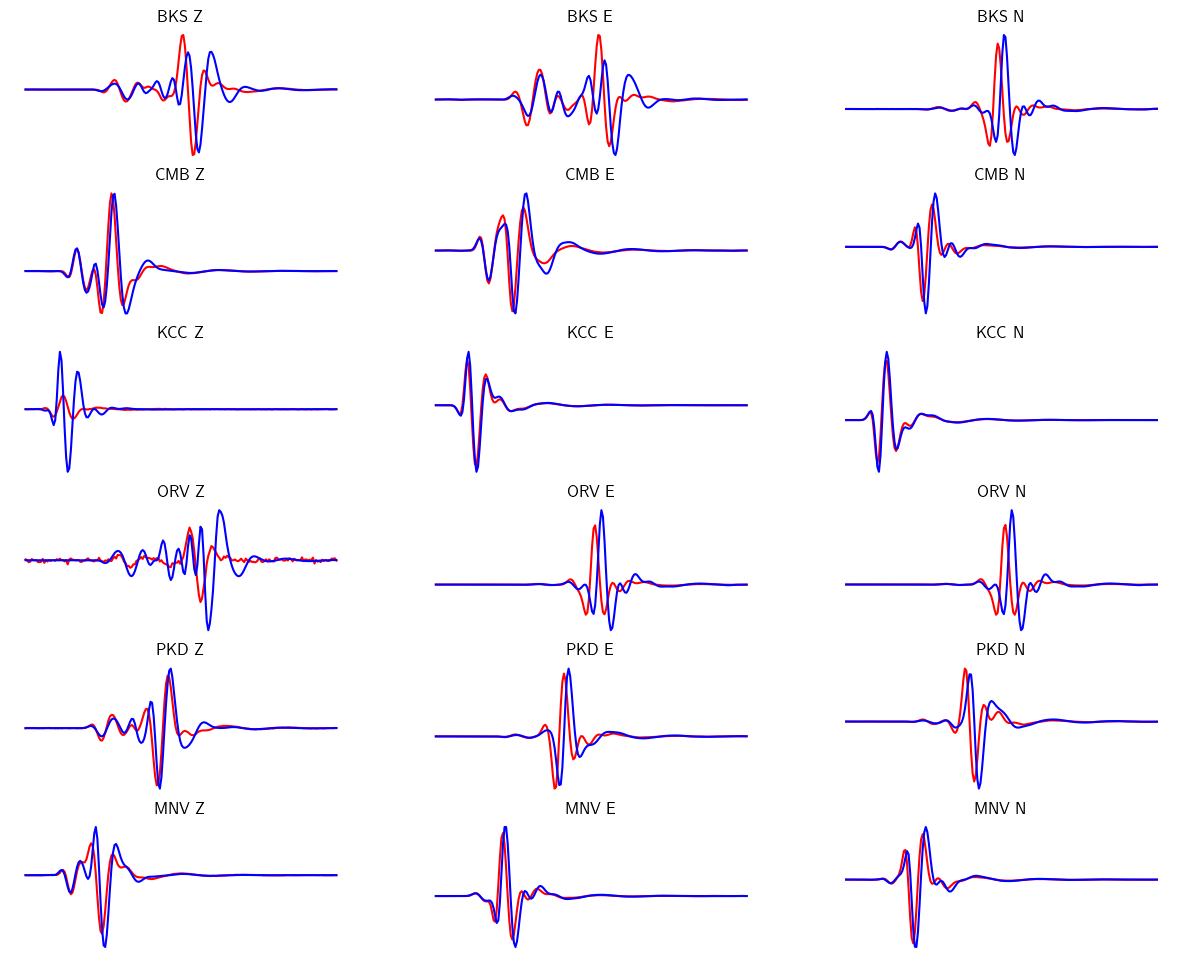

In [69]:
our_solution_MLE = compression_data.data_fiducial

plotter = SBIPipelinePlotter('', sbi_pipeline.parameters)
plotter.plot_synthetic_misfits(
    job_data[0], 
    sbi_pipeline.simulation_parameters.receivers, 
    our_solution_MLE, 
    event_location= (-4.1123, 142.9635),
    only_raw=True,
    savefig=False )


In [110]:
gl_result = next(sbi_pipeline.run_single_gaussian_likelihood_inversion(job_data[0], inference_options['likelihood'], sbi_pipeline.parameters, priors))

Running MCMC chains: 100%|██████████| 40/40 [11:11<00:00, 16.79s/it]


### Posterior Solutions

Finally, we can plot the resulting sample ensembles from the SBI approach (blue) vs. the Gaussian likelihood approach. 

In [111]:
job_data_configuration = dict(  
    real_events=dict( # specify path to the real event data
        # talaud_fixed= '/data/alex/indo_pacific/events_0.5hz/TALAUD_ISLANDS_INDONESIA_20240913_063349_Lat4.5327_Lon126.5069_event_filtered_0.5hz.h5'
    ),
    simulations=dict( # we don't run any artificial events here
        random_events= 0,#100,
        fixed_events= [],
        custom_events= {'synthetic_dc': {'moment_tensor': [1.e+14, -1.e+14, 0 ,0, 0, 0], 'source_location': [37.636, -118.936, 5, 0], 'velocity_model': '/home/alex/work/seismo-sbi/scripts/data/SoCal.plain.txt'}},
    ),
    noise_models=dict(
        gaussian_noises= [1.e-2]
    ),
    plots=dict(
        async_plotting= False,
        test_posteriors= dict(
            chain_consumer= 
                [[['theory_optimal_score', 'gaussian'], ['gaussian_likelihood', 'gaussian_noises_x0.01']]]
        ),
        disable_plotting= False
    )
)

config.parse_jobs_config(job_data_configuration)

Plotting posterior comparisons:   0%|          | 0/1 [00:00<?, ?it/s]WARNING:chainconsumer:Parameter $M_{\theta \theta}$ in chain gaussian_likelihood_gaussian_noises_x0.01 is not constrained


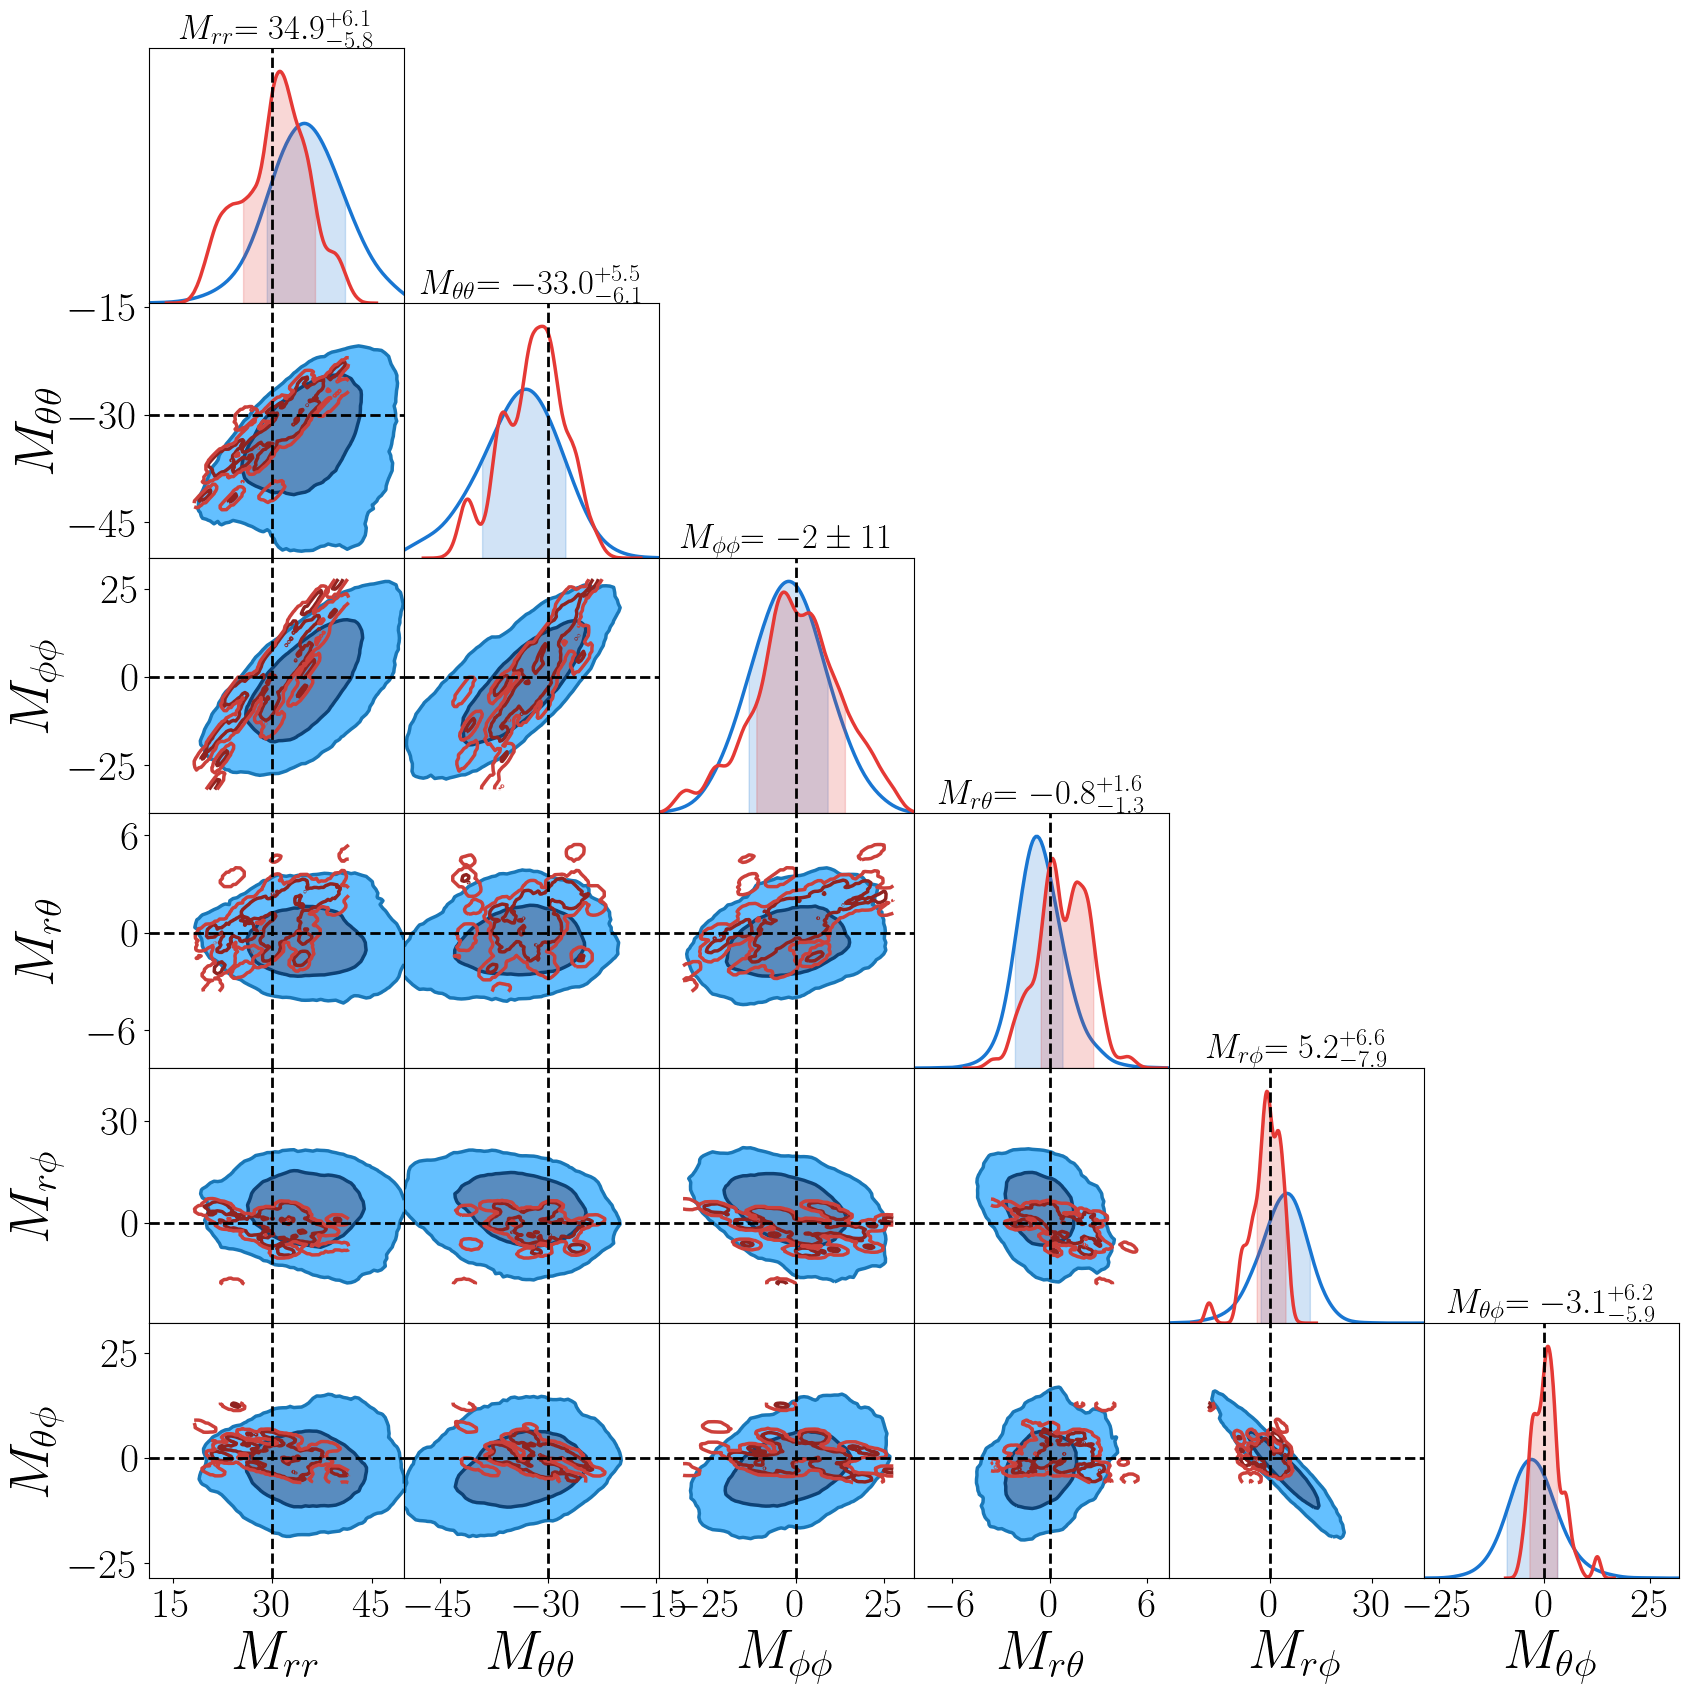

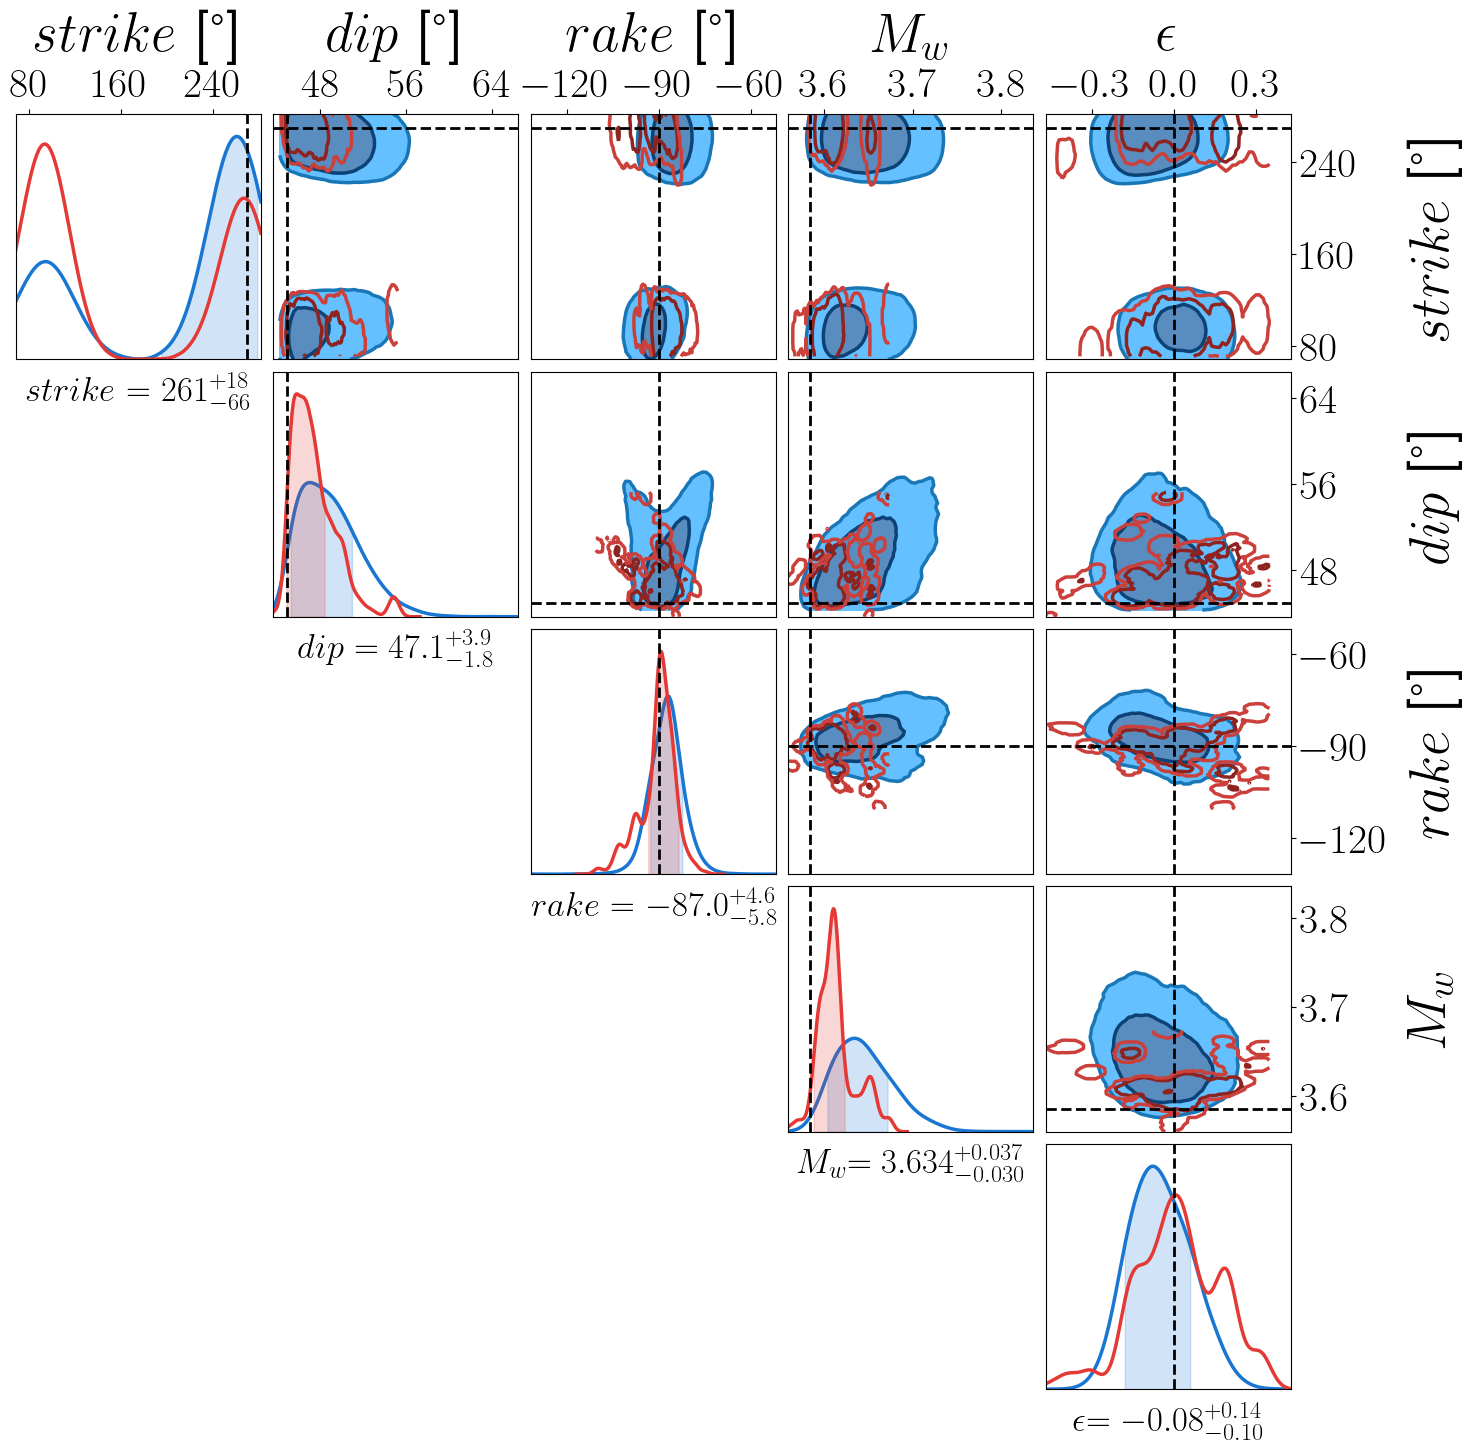

Plotting posterior comparisons: 100%|██████████| 1/1 [00:53<00:00, 53.70s/it]


In [112]:
inversion_results = [inversion_result, gl_result[1]]
sbi_pipeline.plot_comparisons(inversion_results, config.plotting_options['test_posteriors']['chain_consumer'], savefig=False)